# Analyze Trajectories 

- detect movements of parties triggered by crisis
- analyze trajectories of MPs that changed parties

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from aggregation_functions import aggregate_by_mp_year, aggregate_by_party_year

In [2]:
# data frame with speech to topic assignments
df_topics = pd.read_csv('speech_topic_assignments.csv')
df_topics

,speaker_id,party,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name,date
0,11001434,SPD,604683,1,netznutzungsentgelte/wärmegesetz/zuteilungsgesetz,1,netznutzungsentgelte/wärmegesetz/zuteilungsgesetz,2000-01-19
1,11002754,CDU/CSU,604883,3,studienfinanzierung/afbg/bafög-bericht,3,studienfinanzierung/afbg/bafög-bericht,2000-01-20
2,11000431,SPD,604885,3,studienfinanzierung/afbg/bafög-bericht,3,studienfinanzierung/afbg/bafög-bericht,2000-01-20
3,11001180,FDP,604905,22,havariekommando/meerespolitik/wsv,22,havariekommando/meerespolitik/wsv,2000-01-20
4,11003216,CDU/CSU,605067,-1,unassigned,15,soldatenberuf/materialerhaltung/ptbs,2000-01-21
...,...,...,...,...,...,...,...,...
82442,11004381,SPD,1060945,-1,unassigned,24,überhangmandate/stimmgewichts/überhangmandaten,2021-05-07
82443,11004854,CDU/CSU,1060947,-1,unassigned,24,überhangmandate/stimmgewichts/überhangmandaten,2021-05-07
82444,11004802,SPD,1060949,-1,unassigned,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,2021-05-07
82445,11004802,SPD,1060955,-1,unassigned,17,astrazeneca/impfkampagne/epidemische,2021-05-07


In [3]:
# data frame with fine tuned embeddings
df_embeddings = pd.read_parquet("jina_v3_contrastive_full.parquet")
df_embeddings

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,year,year_month,n_tokens,used_in_finetune,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,2000,2000-01,1209,False,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051..."
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,2000,2000-01,988,False,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297..."
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,2000,2000-01,1087,False,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229..."
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,2000,2000-01,1550,False,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038..."
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,2000,2000-01,1552,False,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,991,False,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198..."
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,2021,2021-05,943,False,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153..."
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,1153,False,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076..."
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,197,False,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245..."


In [4]:
# merge embedding and topics data frame
df_embeddings_topics = df_embeddings.merge(
    df_topics.drop(columns=["party", "date"]),
    left_on="id", right_on="speech_id",
    how="inner"
)

df_embeddings_topics

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,...,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051...",11001434,604683,1,netznutzungsentgelte/wärmegesetz/zuteilungsgesetz,1,netznutzungsentgelte/wärmegesetz/zuteilungsgesetz
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,...,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297...",11002754,604883,3,studienfinanzierung/afbg/bafög-bericht,3,studienfinanzierung/afbg/bafög-bericht
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,...,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229...",11000431,604885,3,studienfinanzierung/afbg/bafög-bericht,3,studienfinanzierung/afbg/bafög-bericht
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038...",11001180,604905,22,havariekommando/meerespolitik/wsv,22,havariekommando/meerespolitik/wsv
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,...,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094...",11003216,605067,-1,unassigned,15,soldatenberuf/materialerhaltung/ptbs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198...",11004381,1060945,-1,unassigned,24,überhangmandate/stimmgewichts/überhangmandaten
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153...",11004854,1060947,-1,unassigned,24,überhangmandate/stimmgewichts/überhangmandaten
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076...",11004802,1060949,-1,unassigned,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245...",11004802,1060955,-1,unassigned,17,astrazeneca/impfkampagne/epidemische


## 1. Detect Crisis

We test if the following political events appear as detectable movements in the embedding space (embeddings aggregated by MP and year): 

- 9/11 terror attacks
- Lehman Brothers collapse / global financial crisis
- Fukushima nuclear disaster
- Shift to migration scepticism in Germany (post-Cologne NYE)

To test, whether those events trigger movements of the embeddings, we first have to filter for related topics.


In [5]:
# List of all topics 
print(df_embeddings_topics.topic_emb_full_name.unique())

['netznutzungsentgelte/wärmegesetz/zuteilungsgesetz'
 'studienfinanzierung/afbg/bafög-bericht'
 'havariekommando/meerespolitik/wsv'
 'soldatenberuf/materialerhaltung/ptbs'
 'straßenbaubericht/pällmann-kommission/unfallzahlen'
 'rsa/krankenhausstrukturgesetz/drgs' 'tierhalter/imker/ställe'
 'finanzplatzes/pfandbrief/mittelstandsfinanzierung'
 'mehrstaatigkeit/schutzberechtigten/übermittlungspflichten'
 'volladoption/stiefkindadoption/sukzessivadoption'
 'mietenbericht/bestandsmieten/baulandkommission'
 'juristenausbildung/zpo-reform/zivilprozesses'
 'waldbesitzer/waldbesitzern/waldzustandsbericht'
 'stasi-unterlagen-gesetz/bstu/heimkehrerstiftung'
 'belarussischen/lukaschenko/wahlbeobachtung'
 'kosovarische/kfor-einsatz/eulex' 'engagementstrategie/fsj/föj'
 'polizeibeauftragten/terrorismusabwehrzentrum/mihalic'
 'dreibus/zeitarbeitnehmer/rentenanpassungen'
 'epas/konfliktmineralien/deg'
 'betreuungsausbau/familienbezogenen/haushaltsfreibetrag'
 'buchpreisbindung/buchhandlungen/urheberre

### 9/11 terror attacks
Topics related to 9/11 terror attacks: 
- "isaf-einsatz/karzai/quick" (ISAF deployment (Afghanistan)/Karzai/quick)
- "polizeibeauftragten/terrorismusabwehrzentrum/mihalic" (police commissioner / counter-terrorism center / Mihalic)

In [6]:
df_9_11 = df_embeddings_topics[df_embeddings_topics["topic_emb_raw_name"].isin(["isaf-einsatz/karzai/quick",
    "polizeibeauftragten/terrorismusabwehrzentrum/mihalic"])]

df_9_11

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
31,614040,Wenn wir heute eine Debatte miteinander führen...,11003111,Sebastian Edathy,Sebastian,Edathy,Member of Parliament,23,SPD,2000-09-28,...,False,False,True,"[0.07593365, -0.08972256, 0.0893441, 0.0038220...",11003111,614040,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
344,605699,Als ehemaliges Mitglied der EnqueteKommission ...,11001023,ulla jelpke,ulla,jelpke,Member of Parliament,22,PDS,2000-01-28,...,False,False,True,"[0.10607977, -0.0888114, 0.07785951, 0.0023597...",11001023,605699,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
2302,613631,"Ich glaube, jeder verurteilt diese Demonstrati...",11002746,cem özdemir,cem,özdemir,Member of Parliament,3,Grüne,2000-09-15,...,False,False,True,"[0.07595482, -0.124643795, 0.040917672, 0.0172...",11002746,613631,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
2305,613635,"Herr Schily, auch ich meine, dass Ihre Bilanz,...",11001023,ulla jelpke,ulla,jelpke,Member of Parliament,22,PDS,2000-09-15,...,False,False,True,"[0.04660384, -0.10345503, 0.037094165, 0.01037...",11001023,613635,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
2308,613625,Ich habe nun in 13 Jahren Parlamentszugehörigk...,11002588,wolfgang zeitlmann,wolfgang,zeitlmann,Member of Parliament,4,CDU/CSU,2000-09-15,...,False,False,True,"[0.04881356, -0.105593204, 0.048725087, 0.0301...",11002588,613625,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82347,1060624,"Ich freue mich, zu dieser Primetime über die B...",11004766,Hans-Jürgen Irmer,Hans-Jürgen,Irmer,Member of Parliament,4,CDU/CSU,2021-05-06,...,False,False,True,"[0.043702677, -0.14849974, 0.045589555, 0.0227...",11004766,1060624,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
82360,1060673,Wir bringen heute in erster Lesung den Entwurf...,11004276,Thorsten Frei,Thorsten,Frei,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.09031513, -0.099884175, 0.07600586, 0.01882...",11004276,1060673,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
82362,1060677,Vielen Dank. – Herr Präsident! Liebe Kolleginn...,11004282,Uli Grötsch,Uli,Grötsch,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.100889556, -0.09553122, 0.06049149, 0.00152...",11004282,1060677,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...
82366,1060685,Nicht erst seit dem Bericht des Innenministers...,11004917,Alexander Throm,Alexander,Throm,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.0857694, -0.13032633, 0.03517341, -0.003386...",11004917,1060685,11,polizeibeauftragten/terrorismusabwehrzentrum/m...,11,polizeibeauftragten/terrorismusabwehrzentrum/m...


### Lehman Brothers collapse / global financial crisis
Topic related to Lehman Brothers collapse / global financial crisis: 
- 'finanzplatzes/pfandbrief/mittelstandsfinanzierung' (Financial market/covered bonds/SME financing)

In [7]:
df_financial_crisis = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name == 'finanzplatzes/pfandbrief/mittelstandsfinanzierung']
df_financial_crisis

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
9,606154,"Kollege Brüderle, als Sie in Ihrer Rede Walter...",11003195,Klaus Wolfgang Müller,Klaus Wolfgang,Müller,Member of Parliament,3,Grüne,2000-02-17,...,False,False,True,"[0.044166, -0.046673443, 0.020151215, -0.01457...",11003195,606154,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
10,606144,"Herr Kollege Glos, es ist in diesen Tagen wahr...",11002108,Werner Schulz,Werner,Schulz,Member of Parliament,3,Grüne,2000-02-17,...,False,False,True,"[0.084874205, -0.066379584, -0.008602232, -0.0...",11002108,606144,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
30,613688,Meine verehrten Kolleginnen und Kollegen! Am E...,11000832,hansgeorg hauser,hansgeorg,hauser,Member of Parliament,4,CDU/CSU,2000-09-15,...,False,False,True,"[0.055651758, -0.046117816, 0.02309618, -0.001...",11000832,613688,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
32,614310,Ich möchte mich vor allen Dingen mit dem besch...,11000611,Anke Fuchs,Anke,Fuchs,Member of Parliament,23,SPD,2000-09-29,...,False,False,True,"[0.05125831, -0.11790038, 0.052024458, 0.02114...",11000611,614310,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
33,611115,Wir stehen wahrlich vor großen Aufgaben. Anges...,11003213,Michael Roth,Michael,Roth,Member of Parliament,23,SPD,2000-06-08,...,False,False,True,"[0.0901975, -0.060007904, 0.049492925, 0.00735...",11003213,611115,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82278,1060378,"Wahlen sind eigentlich Feste der Demokratie, u...",11004258,Bernhard Daldrup,Bernhard,Daldrup,Member of Parliament,23,SPD,2021-05-06,...,False,False,True,"[0.054977946, -0.06534267, -0.00624483, -0.006...",11004258,1060378,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
82279,1060380,Geschätzte Kolleginnen und Kollegen! Das Thema...,11004815,Till Mansmann,Till,Mansmann,Member of Parliament,13,FDP,2021-05-06,...,False,False,True,"[0.08686029, -0.064966775, 0.03741426, 0.02124...",11004815,1060380,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
82281,1060388,"Nein, nicht aus der AfD-Fraktion. Danke schön....",11004710,Wiebke Esdar,Wiebke,Esdar,Member of Parliament,23,SPD,2021-05-06,...,False,False,True,"[0.046059754, -0.0650443, 0.010508921, 0.00379...",11004710,1060388,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung
82344,1060614,Vielen Dank. – Herr Präsident! Liebe Kolleginn...,11003050,Lothar Binding,Lothar,Binding,Member of Parliament,23,SPD,2021-05-06,...,False,False,True,"[0.11310496, -0.099049255, 0.01959681, 0.00182...",11003050,1060614,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung,0,finanzplatzes/pfandbrief/mittelstandsfinanzierung


### Fukushima nuclear disaster
Topic related to 'Fukushima nuclear disaster': 
- 'bürgerenergie/atomkonzerne/kohleausstiegsgesetz' (citizen energy/energy companies/coal phase-out act).

In [8]:
df_fukushima = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name == 'bürgerenergie/atomkonzerne/kohleausstiegsgesetz']
df_fukushima

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
17393,677669,"Wie einige von Ihnen sicher wissen, hatte ich ...",11002636,Eva Bulling-Schröter,Eva,Bulling-Schröter,Member of Parliament,6,LINKE,2005-12-01,...,False,False,True,"[0.047297794, -0.10592712, 0.038479187, -0.019...",11002636,677669,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
17592,678380,Mit dem Gesetzentwurf auf Drucksache 16/45 sol...,11003808,Dorothee Menzner,Dorothee,Menzner,Member of Parliament,6,LINKE,2005-12-16,...,False,False,True,"[-0.0010326895, -0.13592538, 0.06556886, -0.01...",11003808,678380,-1,unassigned,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
18018,680235,"Darüber, dass wir mehr Klimaschutz wollen, sin...",11002636,Eva Bulling-Schröter,Eva,Bulling-Schröter,Member of Parliament,6,LINKE,2006-02-09,...,False,False,True,"[0.08060447, -0.094987884, 0.04208428, -0.0451...",11002636,680235,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
18266,681207,Sehr geehrte Kolleginnen und Kollegen! Eigentl...,11003767,hans-kurt hill,hans-kurt,hill,Member of Parliament,6,LINKE,2006-02-17,...,False,False,True,"[0.0757543, -0.09935425, 0.07616765, -0.049098...",11003767,681207,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
18527,682436,"Herr Staatssekretär, Sie haben eben schon die ...",11003808,Dorothee Menzner,Dorothee,Menzner,Member of Parliament,6,LINKE,2006-03-16,...,False,False,True,"[-0.005178718, -0.18061809, 0.027317164, 0.003...",11003808,682436,-1,unassigned,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81398,1057649,Kolleginnen und Kollegen! „Einwegkunststoffken...,11004091,Ralph Lenkert,Ralph,Lenkert,Member of Parliament,6,LINKE,2021-03-25,...,False,False,True,"[0.049165856, -0.06604765, 0.06406775, 0.00465...",11004091,1057649,-1,unassigned,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
81658,1058458,Kolleginnen und Kollegen! Kurz vor Toresschlus...,11004091,Ralph Lenkert,Ralph,Lenkert,Member of Parliament,6,LINKE,2021-04-15,...,False,False,True,"[0.050052, -0.08978343, 0.05370851, -0.0273412...",11004091,1058458,-1,unassigned,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
81976,1059409,"Wer vom Klimaschutz redet, darf vom Verkehr ni...",11004089,Sabine Leidig,Sabine,Leidig,Member of Parliament,6,LINKE,2021-04-22,...,False,False,True,"[0.019164095, -0.14698419, 0.016786516, -0.005...",11004089,1059409,-1,unassigned,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz
82212,1060191,Um es gleich vorweg zu sagen: Die Linke forder...,11004089,Sabine Leidig,Sabine,Leidig,Member of Parliament,6,LINKE,2021-05-05,...,False,False,True,"[-0.012843745, -0.12550826, 0.021541538, 0.011...",11004089,1060191,-1,unassigned,41,bürgerenergie/atomkonzerne/kohleausstiegsgesetz


### Shift to migration scepticism in Germany (post-Cologne NYE)

Topics related to Shift to migration scepticism in Germany (post-Cologne NYE):   
- "mehrstaatigkeit/schutzberechtigten/übermittlungspflichten" (multiple nationality/beneficiaries of protection (asylum status)/data transmission duties)
- "zwangsverheiratungen/einbürgerungen/ehegattennachzug" (forced marriages/naturalizations/spousal reunion (family reunification))
- "militärmission/flüchtlingsabwehr/militärausgaben" (military mission/refugee deterrence/military spending)

In [9]:
df_migration = df_embeddings_topics[df_embeddings_topics["topic_emb_raw_name"].isin(["mehrstaatigkeit/schutzberechtigten/übermittlungspflichten",
    "zwangsverheiratungen/einbürgerungen/ehegattennachzug",
    "militärmission/flüchtlingsabwehr/militärausgaben"])]

df_migration

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
357,605733,Eine vernünftige Regelung des § 19 des Ausländ...,11002805,max stadler,max,stadler,Member of Parliament,13,FDP,2000-01-28,...,False,False,True,"[0.0048696594, -0.104695745, 0.093123056, 0.05...",11002805,605733,7,mehrstaatigkeit/schutzberechtigten/übermittlun...,7,mehrstaatigkeit/schutzberechtigten/übermittlun...
778,607529,Meine lieben Kolleginnen und Kollegen! Ich möc...,11002805,Max Stadler,Max,Stadler,Member of Parliament,13,FDP,2000-03-16,...,False,False,True,"[0.0012502039, -0.095612794, 0.089772105, 0.06...",11002805,607529,7,mehrstaatigkeit/schutzberechtigten/übermittlun...,7,mehrstaatigkeit/schutzberechtigten/übermittlun...
780,607537,Auch wenn dieses Angebot noch so freundlich ge...,11003249,Rüdiger Veit,Rüdiger,Veit,Member of Parliament,23,SPD,2000-03-16,...,False,False,True,"[0.04441368, -0.111941434, 0.08770614, 0.02239...",11003249,607537,7,mehrstaatigkeit/schutzberechtigten/übermittlun...,7,mehrstaatigkeit/schutzberechtigten/übermittlun...
781,607550,"Innenminister Schily hat gesagt, das Problem l...",11003247,Hans-Peter Uhl,Hans-Peter,Uhl,Member of Parliament,4,CDU/CSU,2000-03-16,...,False,False,True,"[0.01720537, -0.1693599, 0.13183902, 0.0236222...",11003247,607550,7,mehrstaatigkeit/schutzberechtigten/übermittlun...,7,mehrstaatigkeit/schutzberechtigten/übermittlun...
782,607553,Danke sehr. Ich komme sofort zum Ende. - Wir b...,11003249,Rüdiger Veit,Rüdiger,Veit,Member of Parliament,23,SPD,2000-03-16,...,False,False,True,"[0.031282075, -0.15121084, 0.09905546, 0.01305...",11003249,607553,7,mehrstaatigkeit/schutzberechtigten/übermittlun...,7,mehrstaatigkeit/schutzberechtigten/übermittlun...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81902,1059191,"Vielen Dank, Frau Präsidentin, für die perfekt...",11003746,Sevim Dağdelen,Sevim,Dağdelen,Member of Parliament,6,LINKE,2021-04-21,...,False,False,True,"[0.08595355, -0.15813349, 0.09710907, -0.08975...",11003746,1059191,25,militärmission/flüchtlingsabwehr/militärausgaben,25,militärmission/flüchtlingsabwehr/militärausgaben
82142,1059911,Die Bundesregierung will den Bundeswehreinsatz...,11004022,Christine Buchholz,Christine,Buchholz,Member of Parliament,6,LINKE,2021-04-23,...,False,False,True,"[0.028274063, -0.1829748, 0.06134319, -0.08977...",11004022,1059911,25,militärmission/flüchtlingsabwehr/militärausgaben,25,militärmission/flüchtlingsabwehr/militärausgaben
82342,1060600,Verehrter Herr Präsident! Meine Damen und Herr...,11003746,Sevim Dağdelen,Sevim,Dağdelen,Member of Parliament,6,LINKE,2021-05-06,...,False,False,True,"[0.06529063, -0.13924554, 0.09349124, -0.05518...",11003746,1060600,25,militärmission/flüchtlingsabwehr/militärausgaben,25,militärmission/flüchtlingsabwehr/militärausgaben
82348,1060630,Verehrte Präsidentin! Sehr geehrte Damen und H...,11004749,Martin Hess,Martin,Hess,Member of Parliament,0,AfD,2021-05-06,...,False,False,True,"[0.047633506, -0.11995026, 0.08252469, 0.01400...",11004749,1060630,7,mehrstaatigkeit/schutzberechtigten/übermittlun...,7,mehrstaatigkeit/schutzberechtigten/übermittlun...


Function to plot trajectories

In [10]:
def plot_trajectory(df, year, timespan, topic):

    # restrict to the years around the event (to make plots more readable)
    df = df[(df["year"] >= timespan[0]) & (df["year"] <= timespan[1])]

    # aggregate the filtered embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # party colors
    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    # plot trajectories
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]
        if len(subset) == 0:
            continue

        plt.plot(subset["dim1"], subset["dim2"], color=color, label=party, marker='o', markersize=3)

        if len(subset) >= 2:
            plt.annotate('', xy=(subset["dim1"].iloc[1], subset["dim2"].iloc[1]),
                                xytext=(subset["dim1"].iloc[0], subset["dim2"].iloc[0]),
                                arrowprops=dict(arrowstyle='->', color=color, lw=2))

        # label the point for the given event year, if present
        year_row = subset[subset["year"] == year]
        if not year_row.empty:
            plt.annotate(str(year),
                        (year_row["dim1"].iloc[0], year_row["dim2"].iloc[0]),
                        fontsize=8, color=color,
                        textcoords="offset points", xytext=(5, 5))
        
    

    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.axis("off")
    plt.title(f"Trajectories of Party-Year Embeddings ({topic})")
    plt.tight_layout()
    plt.show()



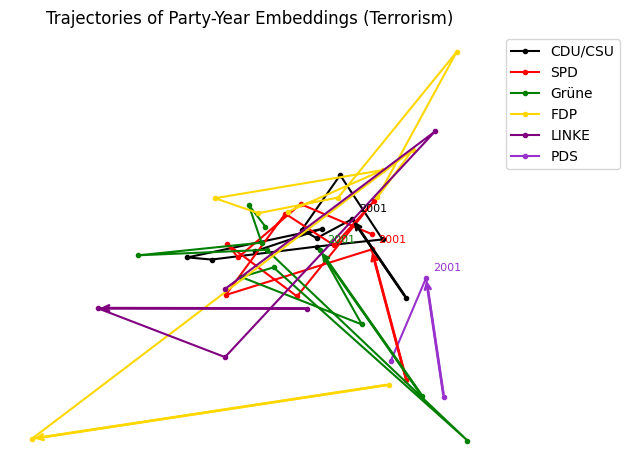

In [11]:
plot_trajectory(df_9_11, 2001, [2000, 2010], 'Terrorism')

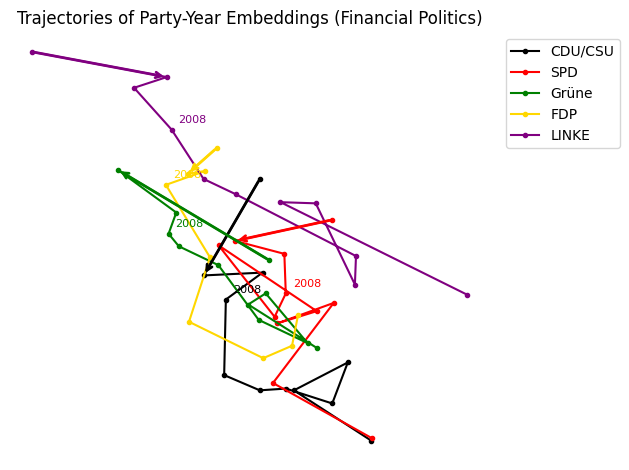

In [12]:
plot_trajectory(df_financial_crisis, 2008, [2005, 2015], 'Financial Politics')

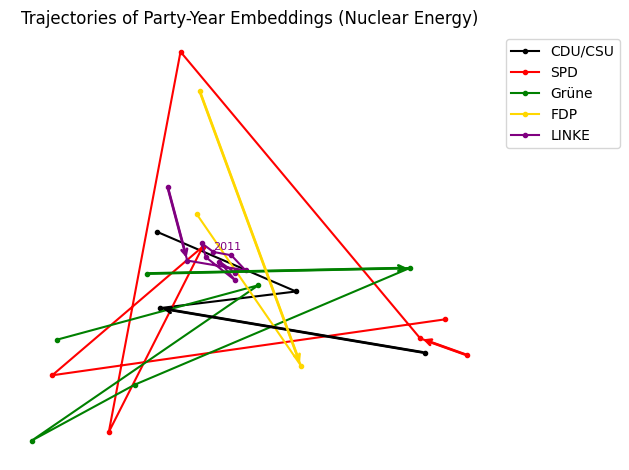

In [13]:
plot_trajectory(df_fukushima, 2011, [2005, 2015], 'Nuclear Energy')

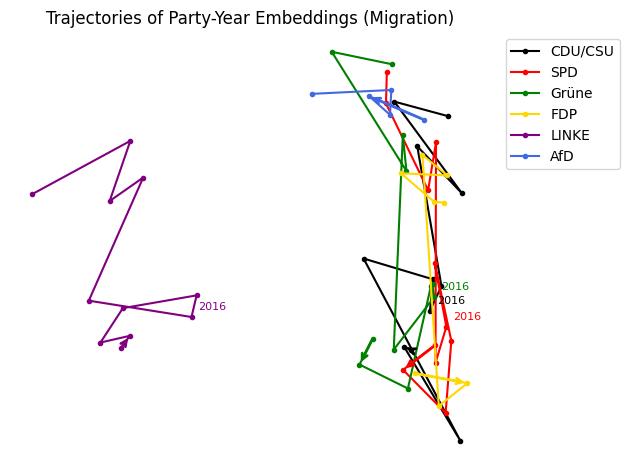

In [14]:
plot_trajectory(df_migration, 2016, [2011, 2021], 'Migration')

In [22]:
def plot_trajectory_per_party(df, year, topic):

    # aggregate the embeddings by party and year (no time restriction)
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # party colors
    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    # one plot per party
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]
        if len(subset) == 0:
            continue

        plt.figure(figsize=(6, 5))
        plt.plot(subset["dim1"], subset["dim2"], color=color, marker='o', markersize=3)

        # arrows between all consecutive points, to show the full trajectory direction
        for i in range(len(subset) - 1):
            plt.annotate('', xy=(subset["dim1"].iloc[i+1], subset["dim2"].iloc[i+1]),
                                xytext=(subset["dim1"].iloc[i], subset["dim2"].iloc[i]),
                                arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))

        # label every year
        for i in range(len(subset)):
            plt.annotate(str(subset["year"].iloc[i]),
                        (subset["dim1"].iloc[i], subset["dim2"].iloc[i]),
                        fontsize=8, color=color,
                        textcoords="offset points", xytext=(5, 5))

        # highlight the event year, if present
        year_row = subset[subset["year"] == year]
        if not year_row.empty:
            plt.scatter(year_row["dim1"], year_row["dim2"], color=color,
                        s=80, edgecolors="black", zorder=5)

        plt.axis("off")
        plt.title(f"{party} — Trajectory of Year Embeddings ({topic})")
        plt.tight_layout()
        plt.show()

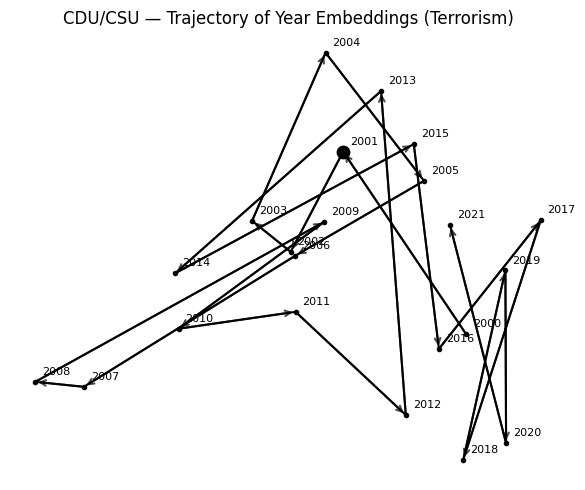

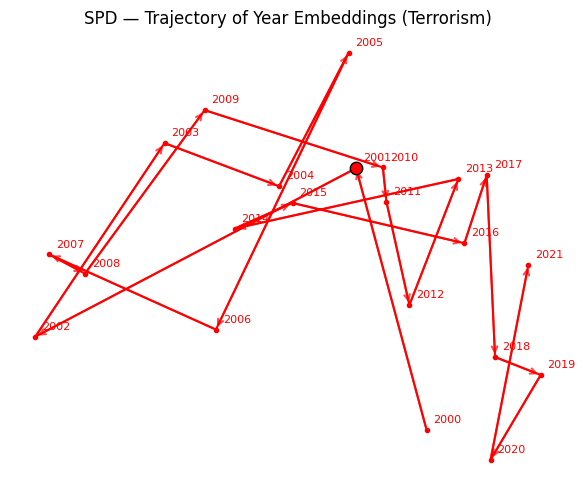

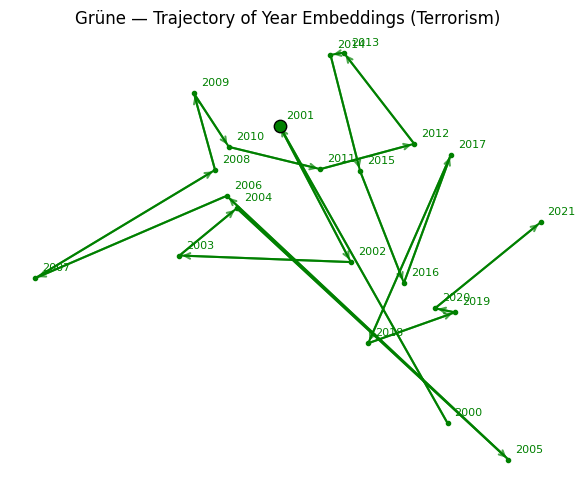

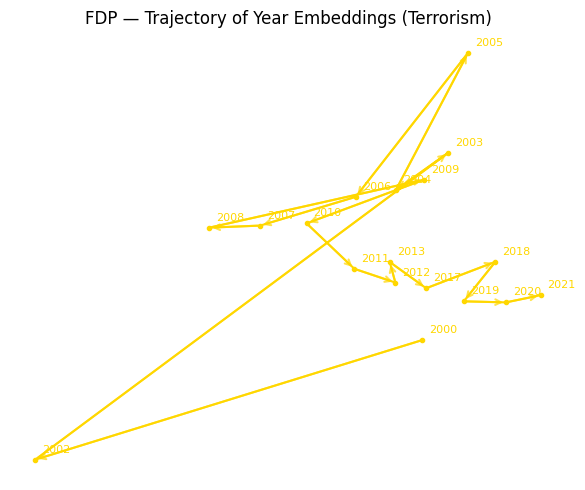

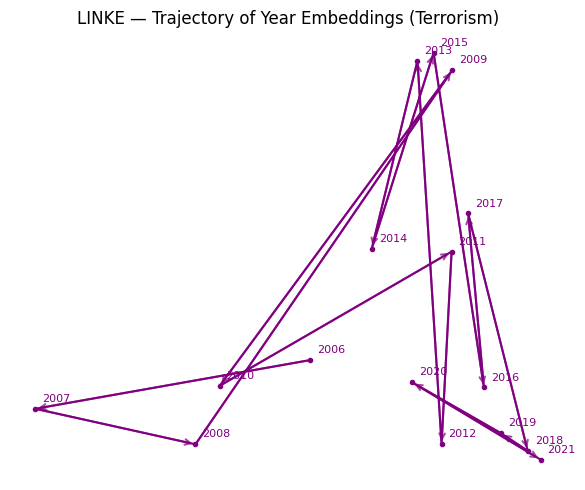

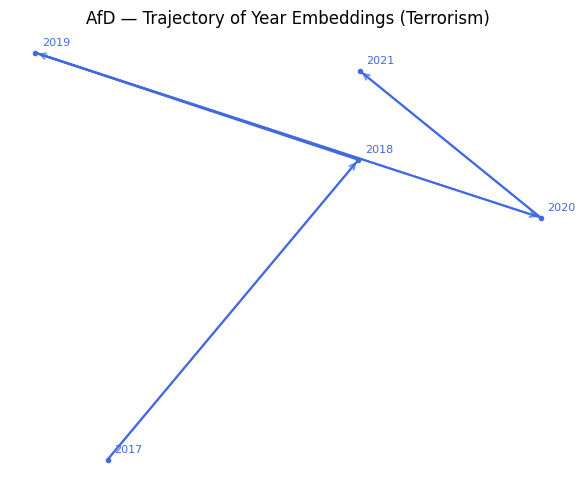

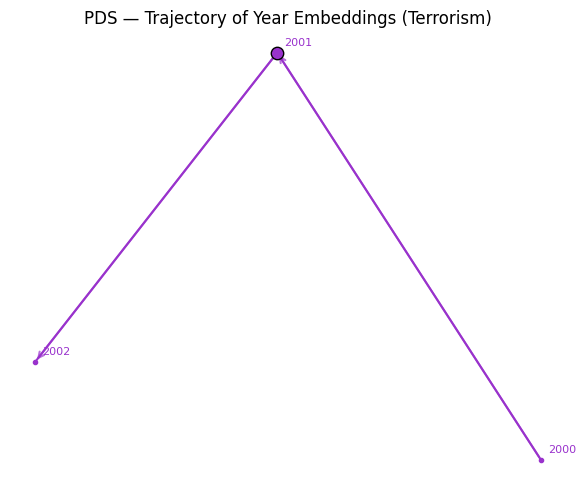

In [23]:
plot_trajectory_per_party(df_9_11, 2001, 'Terrorism')

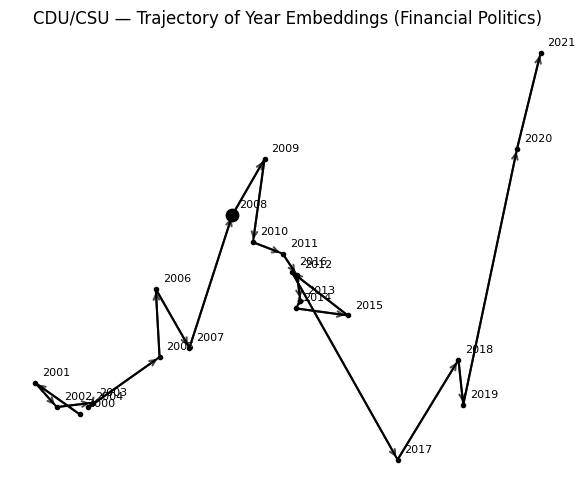

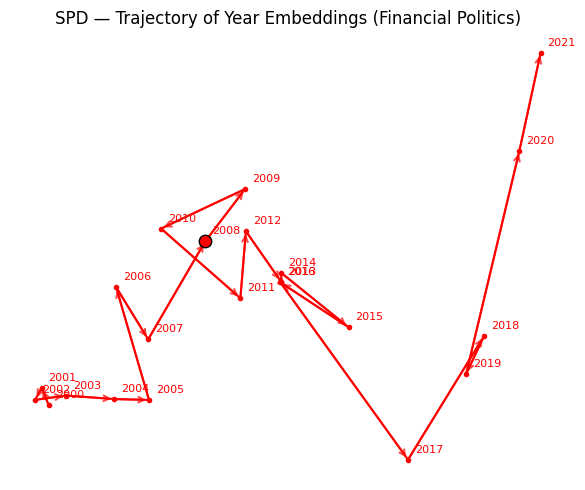

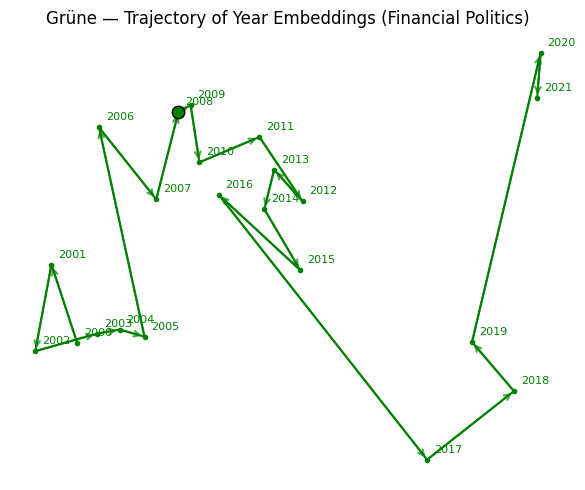

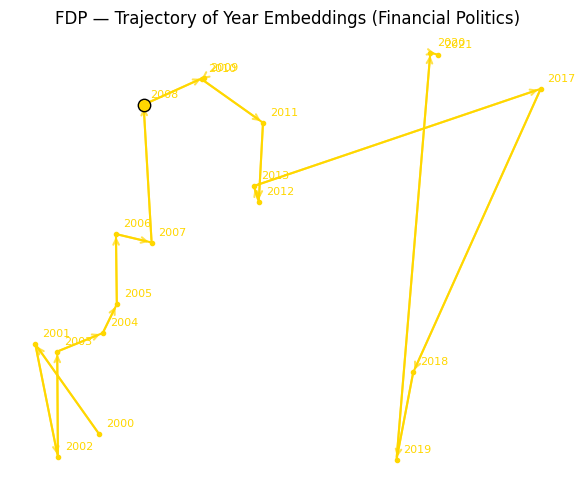

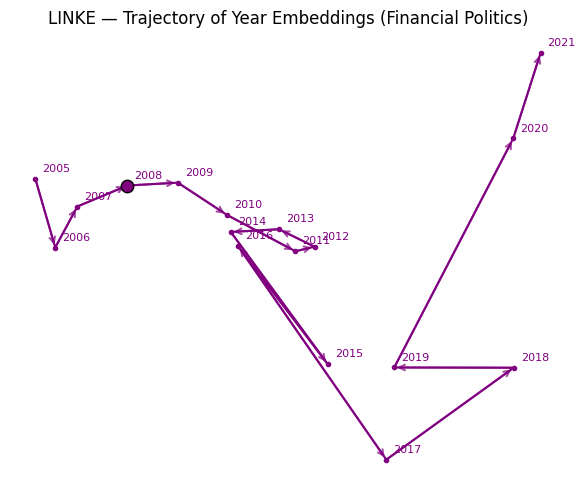

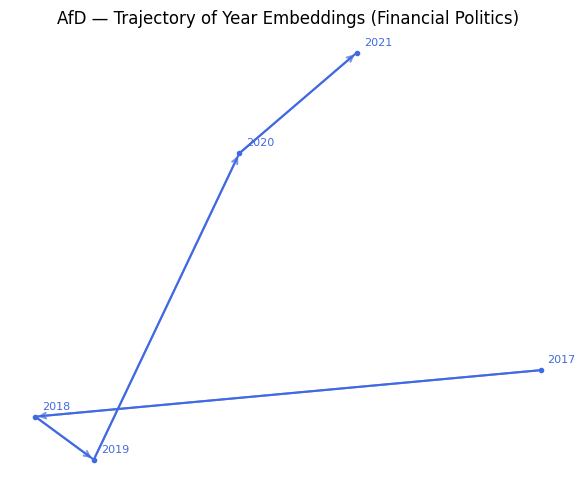

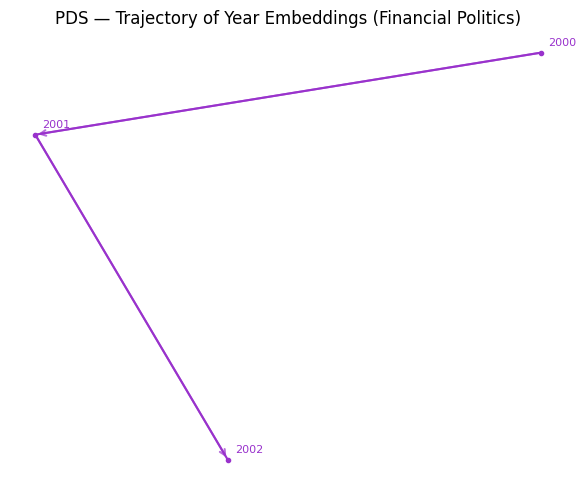

In [24]:
plot_trajectory_per_party(df_financial_crisis, 2008, 'Financial Politics')

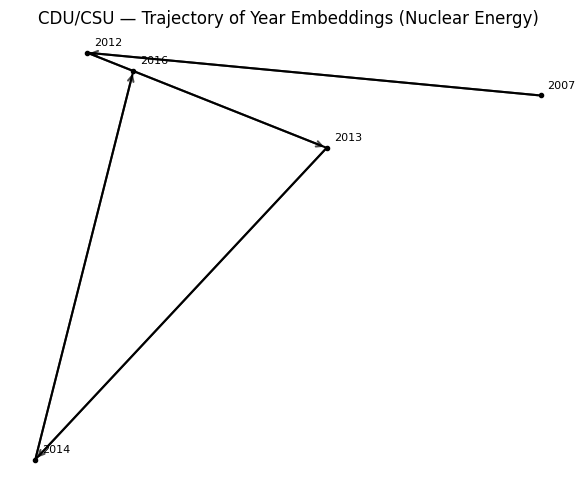

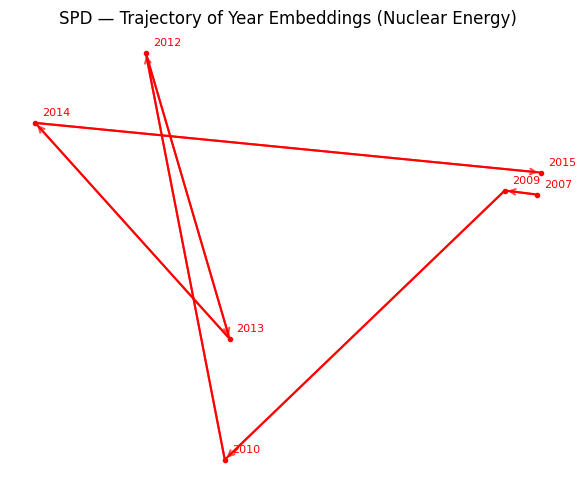

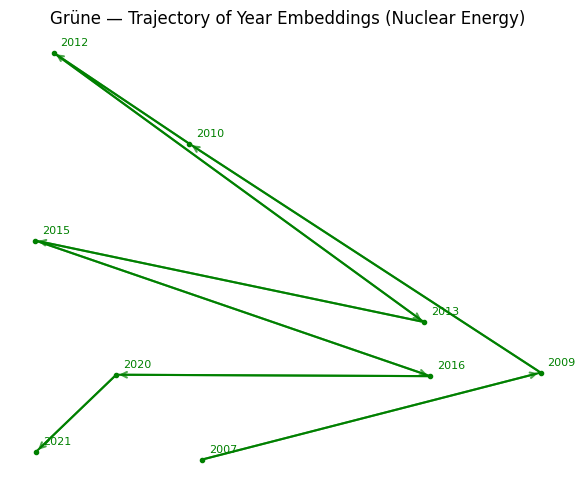

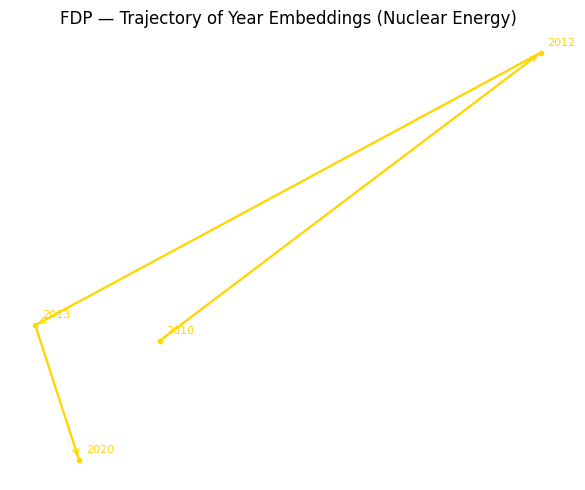

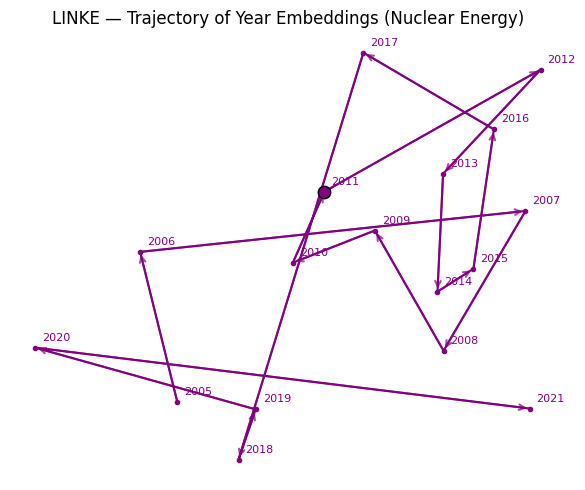

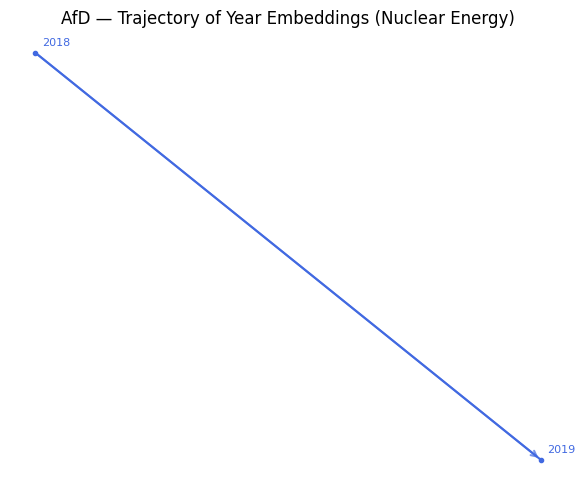

In [25]:
plot_trajectory_per_party(df_fukushima, 2011, 'Nuclear Energy')

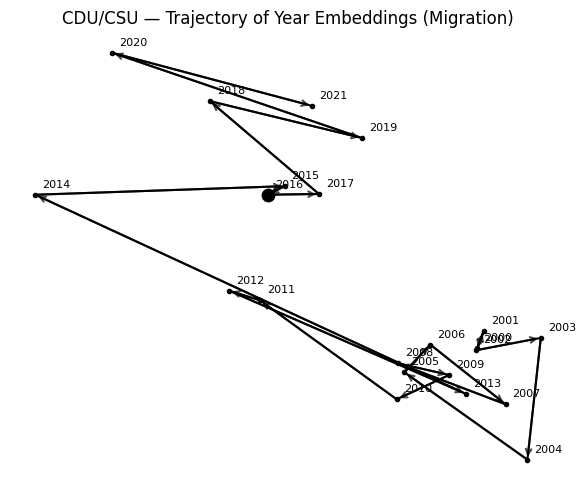

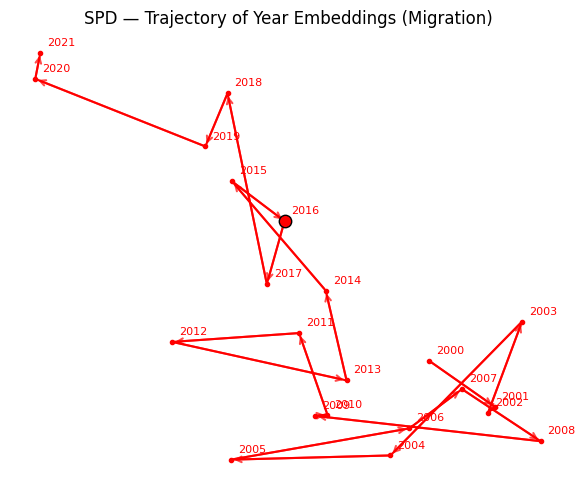

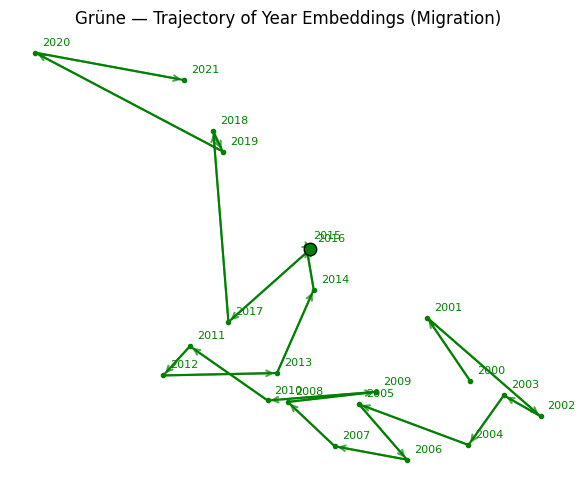

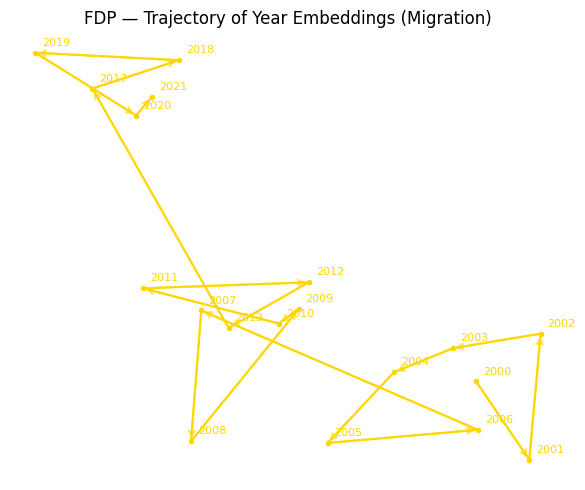

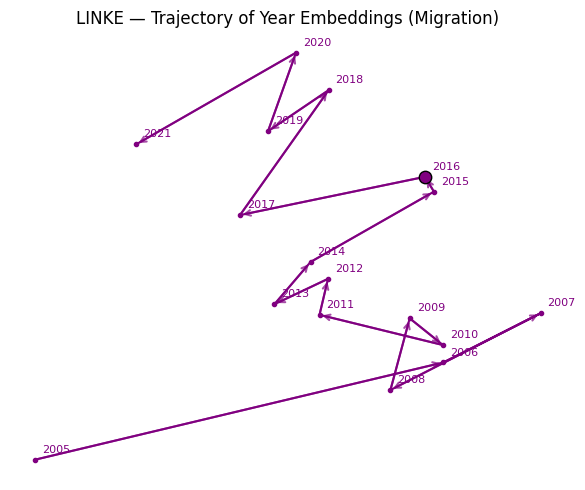

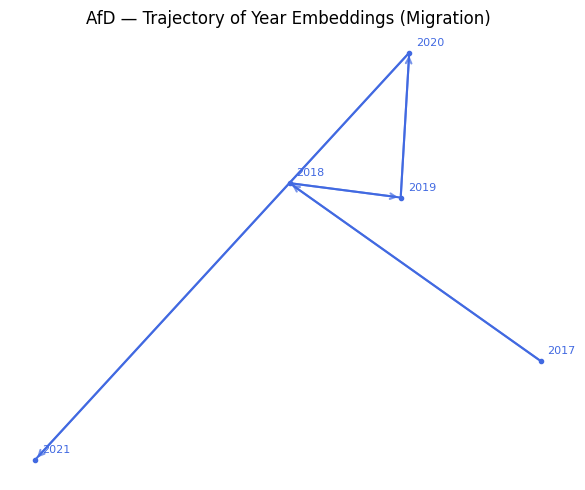

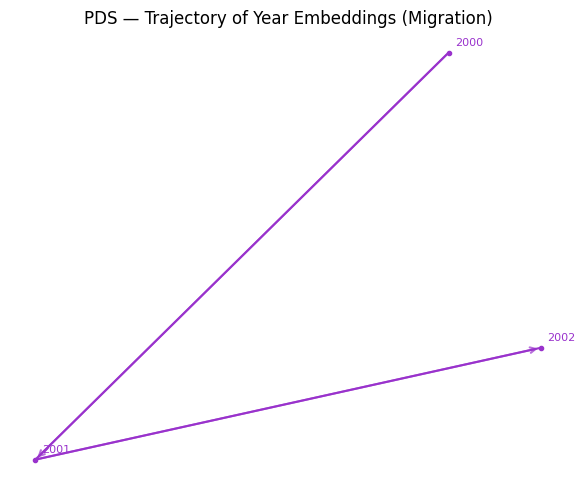

In [26]:
plot_trajectory_per_party(df_migration, 2016, 'Migration')

In [17]:
def plot_trajectory_1d(df, year, topic):

    # aggregate the embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to one dimension
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # party colors
    party_colors = {
        "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
        "FDP": "gold", "LINKE": "purple", "AfD": "royalblue",
        "PDS": "darkorchid"
    }

    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]
        if len(subset) == 0:
            continue
        plt.plot(subset["year"], subset["pc1"], color=color, label=party, marker='o', markersize=3)

    # mark the event year
    plt.axvline(year, color="grey", linestyle="--", linewidth=1)

    plt.xlabel("Year")
    plt.ylabel("PC1")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.title(f"PC1 of Party-Year Embeddings over Time ({topic})")
    plt.tight_layout()
    plt.show()

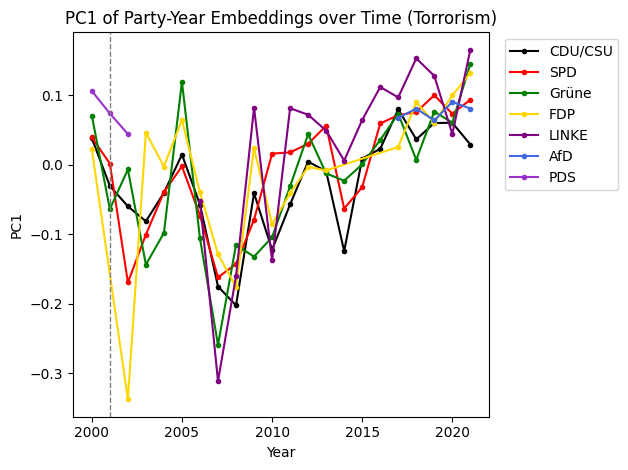

In [18]:
plot_trajectory_1d(df_9_11, 2001, 'Torrorism')

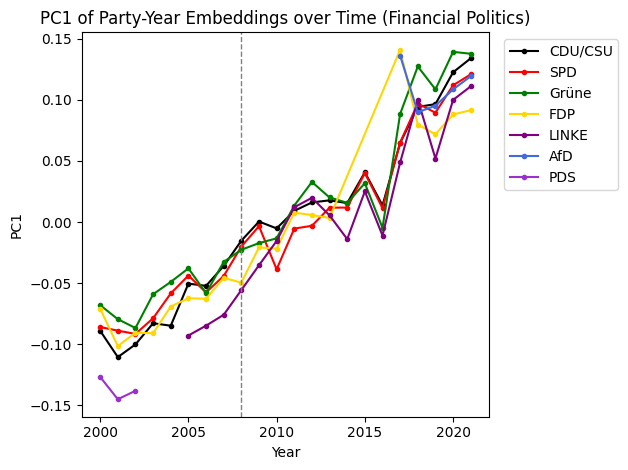

In [20]:
plot_trajectory_1d(df_financial_crisis, 2008, 'Financial Politics')

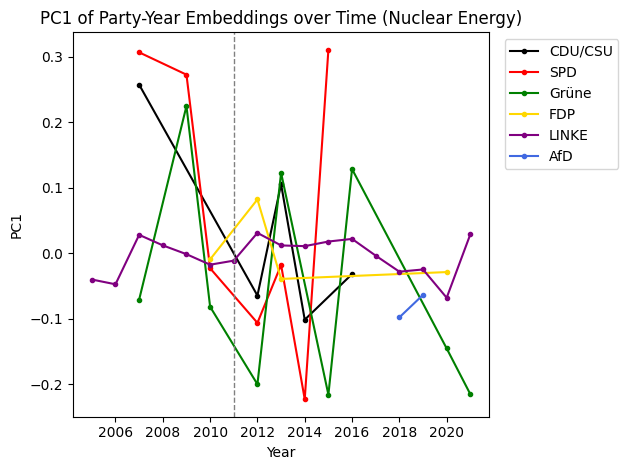

In [19]:
plot_trajectory_1d(df_fukushima, 2011, 'Nuclear Energy')

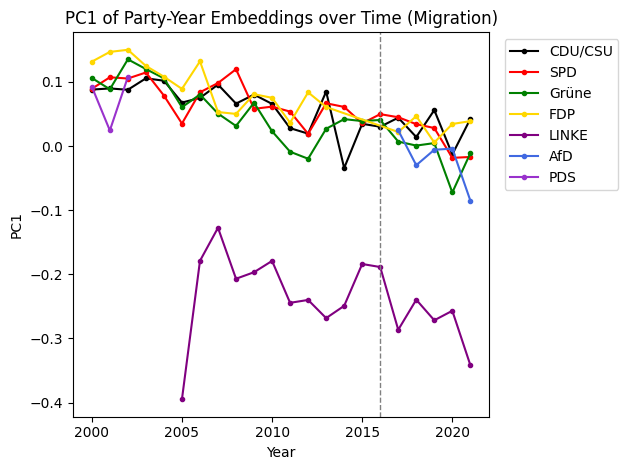

In [21]:
plot_trajectory_1d(df_migration, 2016, 'Migration')